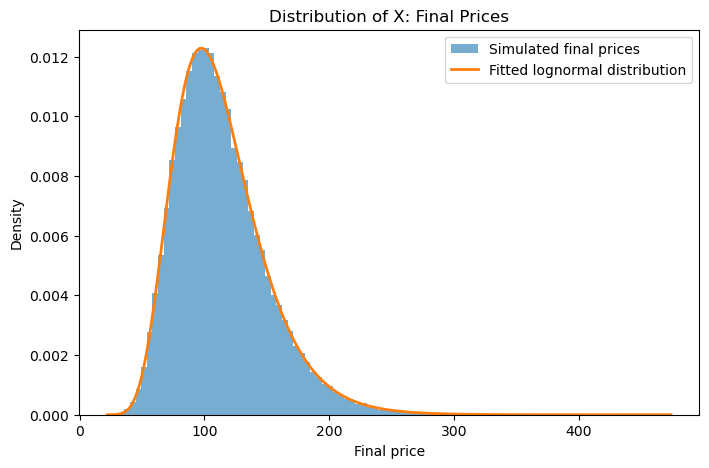

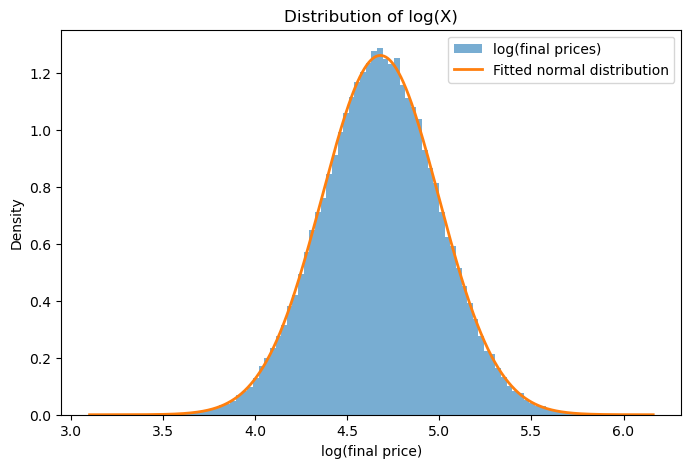

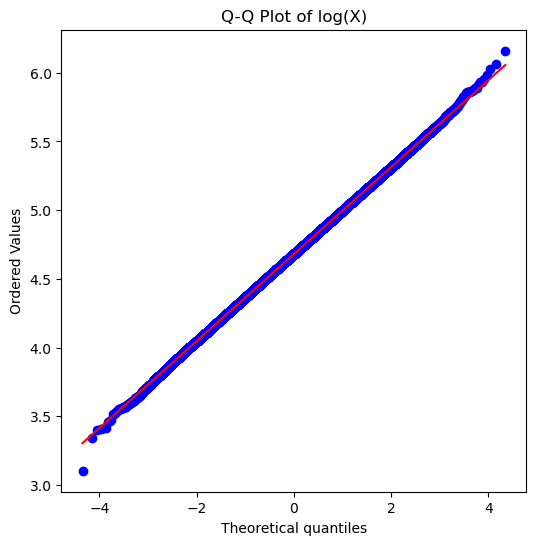

Final prices:
Mean:   113.3612
Median: 107.8598
Std:    36.7919

log(Final prices):
Mean:   4.6805
Std:    0.3166

Theoretical log(X) parameters:
Theoretical mean of log(X): 4.6808
Theoretical std of log(X):  0.3175


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, lognorm, probplot

# 固定隨機種子，方便重現結果
np.random.seed(42)

# 模擬參數
num_samples = 100_000  # 模擬 100,000 條路徑
num_steps = 252  # 假設一年 252 個交易日
initial_price = 100  # 初始價格

# 假設每日「對數報酬」服從常態分佈
# 平均每日報酬約 0.03%，每日波動約 2%
mu = 0.0003
sigma = 0.02

# 產生每日對數報酬
log_returns = np.random.normal(loc=mu, scale=sigma, size=(num_samples, num_steps))

# 對數報酬相加
total_log_returns = log_returns.sum(axis=1)

# 股票價格 = 初始價格 * exp(累積對數報酬)
final_prices = initial_price * np.exp(total_log_returns)

# 取 final_prices 的對數
log_final_prices = np.log(final_prices)


# -----------------------------
# 圖 1：X 本身的分佈
# -----------------------------
plt.figure(figsize=(8, 5))
plt.hist(
    final_prices, bins=100, density=True, alpha=0.6, label="Simulated final prices"
)

# 配適對數常態分佈
shape, loc, scale = lognorm.fit(final_prices, floc=0)
x = np.linspace(final_prices.min(), final_prices.max(), 1000)
pdf_lognorm = lognorm.pdf(x, shape, loc=loc, scale=scale)

plt.plot(x, pdf_lognorm, linewidth=2, label="Fitted lognormal distribution")
plt.title("Distribution of X: Final Prices")
plt.xlabel("Final price")
plt.ylabel("Density")
plt.legend()
plt.show()


# -----------------------------
# 圖 2：log(X) 的分佈
# -----------------------------
plt.figure(figsize=(8, 5))
plt.hist(log_final_prices, bins=100, density=True, alpha=0.6, label="log(final prices)")

# 配適常態分佈
mean_log = np.mean(log_final_prices)
std_log = np.std(log_final_prices)

x_log = np.linspace(log_final_prices.min(), log_final_prices.max(), 1000)
pdf_norm = norm.pdf(x_log, loc=mean_log, scale=std_log)

plt.plot(x_log, pdf_norm, linewidth=2, label="Fitted normal distribution")
plt.title("Distribution of log(X)")
plt.xlabel("log(final price)")
plt.ylabel("Density")
plt.legend()
plt.show()


# -----------------------------
# 圖 3：Q-Q plot 檢查 log(X) 是否接近常態
# -----------------------------
plt.figure(figsize=(6, 6))
probplot(log_final_prices, dist="norm", plot=plt)
plt.title("Q-Q Plot of log(X)")
plt.show()


# -----------------------------
# 輸出統計結果
# -----------------------------
print("Final prices:")
print(f"Mean:   {np.mean(final_prices):.4f}")
print(f"Median: {np.median(final_prices):.4f}")
print(f"Std:    {np.std(final_prices):.4f}")

print("\nlog(Final prices):")
print(f"Mean:   {mean_log:.4f}")
print(f"Std:    {std_log:.4f}")

print("\nTheoretical log(X) parameters:")
print(f"Theoretical mean of log(X): {np.log(initial_price) + num_steps * mu:.4f}")
print(f"Theoretical std of log(X):  {np.sqrt(num_steps) * sigma:.4f}")